# Simple Linear Regression I: Python Companion

**ENGR 1451/2451 · Exploratory Data Science · w06a**


## 1. Setup

We will use 2017 county data and aggregate it to the state level. The goal is to fit and interpret a simple linear regression with **HS graduate rate (%)** as the predictor and **poverty rate (%)** as the response.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.precision", 3)


## 2. Load and aggregate the 2017 data

The source file contains county percentages, so we use county population to form population-weighted state averages. The resulting table has one row for each state plus the District of Columbia.

> **Note:** Population weighting is an approximation because the ideal denominator for each percentage is not necessarily total population.


In [3]:
path = Path("data/county_complete.csv")
counties = pd.read_csv(path)

year = "2017"
pop_col = f"pop{year}"
hs_col = f"hs_grad_{year}"
poverty_col = f"poverty_{year}"

county_data = counties[
    ["state", pop_col, hs_col, poverty_col]
].dropna().copy()

county_data["hs_weighted"] = county_data[hs_col] * county_data[pop_col]
county_data["poverty_weighted"] = county_data[poverty_col] * county_data[pop_col]

state_data = (
    county_data
    .groupby("state", as_index=False)
    .agg(
        population=(pop_col, "sum"),
        hs_weighted=("hs_weighted", "sum"),
        poverty_weighted=("poverty_weighted", "sum"),
    )
)

state_data["hs_grad"] = state_data["hs_weighted"] / state_data["population"]
state_data["poverty"] = state_data["poverty_weighted"] / state_data["population"]

state_data = state_data[
    ["state", "population", "hs_grad", "poverty"]
].copy()

print(f"State-level observations: {len(state_data)}")
display(state_data.head())


State-level observations: 51


,state,population,hs_grad,poverty
0,Alabama,4.875e+06,85.419,17.926
1,Alaska,7.258e+05,92.449,9.866
2,Arizona,7.016e+06,86.485,16.925
3,Arkansas,3.004e+06,85.646,18.098
4,California,3.954e+07,82.319,15.116


## 3. Plot before fitting

A scatterplot shows the direction, form, strength, and any unusual observations before we summarize the relationship with a line.


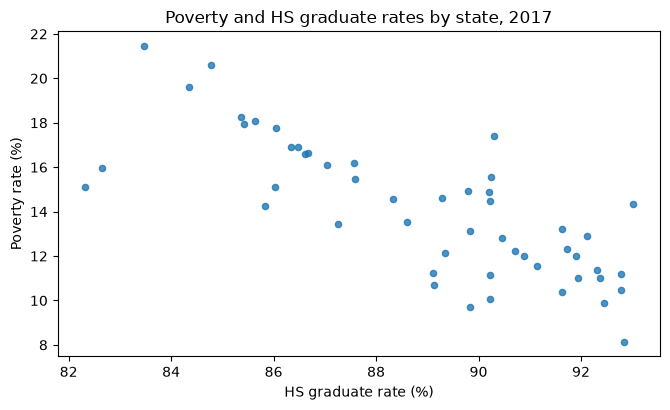

Correlation: -0.774


In [4]:
ax = state_data.plot.scatter(
    x="hs_grad",
    y="poverty",
    figsize=(6.8, 4.2),
    alpha=0.8,
)

ax.set(
    xlabel="HS graduate rate (%)",
    ylabel="Poverty rate (%)",
    title=f"Poverty and HS graduate rates by state, {year}",
)

plt.tight_layout()
plt.show()

r = state_data["hs_grad"].corr(state_data["poverty"])
print(f"Correlation: {r:.3f}")


## 4. Fit the least-squares line

`np.polyfit(x, y, deg=1)` fits a straight line by least squares and returns the **slope first** and **intercept second**.


In [5]:
x = state_data["hs_grad"]
y = state_data["poverty"]

slope, intercept = np.polyfit(x, y, deg=1)

print(f"Slope: {slope:.6f}")
print(f"Intercept: {intercept:.6f}")
print(f"Fitted line: poverty = {intercept:.3f} {slope:+.6f} * hs_grad")


Slope: -0.806625
Intercept: 85.789160
Fitted line: poverty = 85.789 -0.806625 * hs_grad


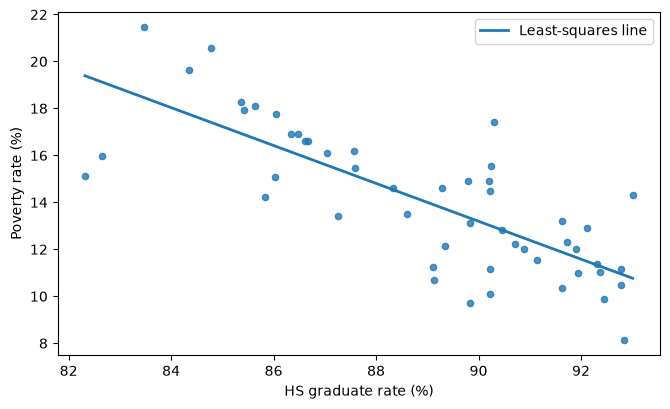

In [6]:
x_line = np.array([x.min(), x.max()])
y_line = intercept + slope * x_line

ax = state_data.plot.scatter(
    x="hs_grad",
    y="poverty",
    figsize=(6.8, 4.2),
    alpha=0.8,
)

ax.plot(x_line, y_line, linewidth=2, label="Least-squares line")
ax.set(
    xlabel="HS graduate rate (%)",
    ylabel="Poverty rate (%)",
)
ax.legend()

plt.tight_layout()
plt.show()


The slope gives the predicted change in poverty rate, in percentage points, associated with a one-percentage-point difference in HS graduate rate across states. A negative slope means states with higher HS graduate rates tend to have lower predicted poverty rates.

This is an **association**, not a demonstrated causal effect.


## 5. Use the fitted line for prediction

Use the fitted coefficients directly in

\[
\widehat{y}=b_0+b_1x.
\]

For example, predict the poverty rate at **Georgia's HS graduate rate** and compare it with Georgia's observed poverty rate.


In [7]:
georgia_hs = state_data.loc[
    state_data["state"].eq("Georgia"), "hs_grad"
].iloc[0]

georgia_observed = state_data.loc[
    state_data["state"].eq("Georgia"), "poverty"
].iloc[0]

georgia_prediction = intercept + slope * georgia_hs

print(f"Georgia HS graduate rate: {georgia_hs:.1f}%")
print(f"Predicted poverty rate:   {georgia_prediction:.2f}%")
print(f"Observed poverty rate:    {georgia_observed:.1f}%")


Georgia HS graduate rate: 86.3%
Predicted poverty rate:   16.15%
Observed poverty rate:    16.9%


The regression line describes an average trend, so an individual state's observed value does not have to fall exactly on the line.


## 6. Reversing the prediction direction

To predict HS graduate rate from poverty, **swap the variables and refit**. Rearranging the original equation is not the same as fitting the reverse regression.


In [8]:
reverse_slope, reverse_intercept = np.polyfit(y, x, deg=1)

print(f"Reverse slope: {reverse_slope:.6f}")
print(f"Reverse intercept: {reverse_intercept:.6f}")
print(
    f"Reverse fitted line: hs_grad = {reverse_intercept:.3f} "
    f"{reverse_slope:+.6f} * poverty"
)


Reverse slope: -0.742731
Reverse intercept: 99.365423
Reverse fitted line: hs_grad = 99.365 -0.742731 * poverty


## 7. Python reference

| Task | Python |
|---|---|
| Fit a straight line | `slope, intercept = np.polyfit(x, y, deg=1)` |
| Make predictions from the line | `y_hat = intercept + slope * x_new` |
| Select rows meeting a condition | `df.loc[df["state"] == "Georgia", "hs_grad"]` |
| Extract the first matching value | `.iloc[0]` |
| Create a NumPy array | `np.array([82.0, 90.0])` |
| Smallest / largest value | `x.min()`, `x.max()` |


## 8. Your turn

Using the state-level data and fitted models above:

1. Use the **original poverty-on-HS-graduate-rate line** to predict poverty at HS graduate rates of **82% and 90%**.
2. Calculate the predicted change in poverty rate from 82% to 90% HS graduation.
3. Use the **reverse regression** to predict HS graduate rate when the poverty rate is **12%**.
4. For comparison, also rearrange the original regression line to solve for HS graduate rate when poverty is 12%. Compare the two results.


In [9]:
practice_rates = np.array([82.0, 90.0])
new_poverty = 12.0

# Your code here:
# 1. Predict poverty for both HS graduate rates.
class LSRL:
    def __init__(self, slope, intercept):
        self.slope = slope
        self.intercept = intercept

    def eval(self, x):
        return self.slope * x + self.intercept

    def reverse_eval(self,y):
        #y = self.slope * x + self.intercept
        return (y-self.intercept)/self.slope

model_hs = LSRL(slope,intercept)

hs_82 = model_hs.eval(82)
hs_90 = model_hs.eval(90)

# 2. Calculate the predicted change from 82% to 90%.
predicted_change = hs_90 - hs_82

# 3. Predict HS graduate rate at 12% poverty using the reverse regression.
model_hs_reverse = LSRL(reverse_slope,reverse_intercept)
pov_12_reverse = model_hs_reverse.eval(12)

# 4. Rearrange the original regression line and compare the result.
pov_12_original = model_hs.reverse_eval(12)

print("Predicted poverty rate at 82% HS graduation rate  =",round(hs_82,2),
      "\nPredicted poverty rate at 90% HS graduation rate  =",round(hs_90,2),
      "\nPredicted change in poverty rate from 82% to 90% HS graduation rate  =",round(predicted_change,2),
      "\nReverse regression estimate for HS graduation rate given a poverty rate of 12%  = ",round(pov_12_reverse,2),
      "\nOriginal regression estimate for HS graduation rate given a poverty rate of 12%  = ",round(pov_12_original,2)
)


Predicted poverty rate at 82% HS graduation rate  = 19.65 
Predicted poverty rate at 90% HS graduation rate  = 13.19 
Predicted change in poverty rate from 82% to 90% HS graduation rate  = -6.45 
Reverse regression estimate for HS graduation rate given a poverty rate of 12%  =  90.45 
Original regression estimate for HS graduation rate given a poverty rate of 12%  =  91.48


**Your interpretation:**

- Predicted poverty at 82% HS graduation:  
- Predicted poverty at 90% HS graduation:  
- Predicted change in poverty rate:  
- Predicted HS graduate rate from the reverse regression:  
- HS graduate rate from rearranging the original line:  
- Why are the last two values not necessarily the same?  
- One-sentence caution about causation:  
